## **1. Introduction**
The goal of this notebook is to use the trained EfficientNet model to compare different class-conditional conformal prediction methods. For this purpose, we use functions adapted from [repository](https://github.com/tiffanyding/class-conditional-conformal).

Remark (01/10/2025): Introduced a plot that splits CovGap and AvgSize into two separate charts.



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **2. Libraries**

In [2]:
# Library
import re
import os
import sys
import torch
import random
import warnings
import cv2 as cv
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
import plotly.subplots as sp
import plotly.graph_objects as go
import seaborn as sns
import contextlib
import io


import timm
import time
import math
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, f1_score
import cv2
import matplotlib.pyplot as plt
from albumentations import Compose, Normalize
from albumentations.pytorch import ToTensorV2
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from contextlib import contextmanager

import sys

# Local Modules
sys.path.append('/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/WMDD_application/utils')


from general_utils import (
    image_path_generation,
    image_path_generation_aug,
    plot_label_distribution,
    get_model_probs,
    evaluate_model,
    prepare_data, # for conformal
    #get_scores
)

#from dataset_utils import (
#    TrainDataset,
#    get_transforms
#)

#from model_utils import (
#    Model_type
#)

from conformal_utils import *
from effnet_utils import *
#import cfg_effnet as cfg


## **3. General Utils**

In [3]:
# Okabe–Ito palette (colorblind-safe)
#---------------------------------------------------
OKABE_ITO = {
    "blue":  "#0072B2",
    "orange":"#E69F00",
    "green": "#009E73",
    "yellow":"#F0E442",
    "red":   "#D55E00",
    "purple":"#CC79A7",
    "sky":   "#56B4E9",
    "black": "#000000"
}

def plot_covgap_avgsize_single(
    summary_df: pd.DataFrame,
    covgap_y_column: str, covgap_yerr_column: str,
    avgsize_y_column: str,  avgsize_yerr_column: str,
    model: str | None = None,                 # optional: filter a specific model if 'Model' column exists
    figure_title: str | None = None,          # optional figure title

    # y-limits (if None, computed from mean ± scale*err with padding)
    covgap_ylim=None, avgsize_ylim=None,

    # output paths
    save_path_pdf: str | None = None,
    save_path_png: str | None = None,

    # --- Layout / styling ---
    base_font: float = 9.0,       # aligned with your set_paper_style default
    tick_mult: float = 0.95,
    title_mult: float = 1.0,
    ms_cov: float = 1.6,
    ms_avg: float = 1.6,
    capsize: float = 3.2,
    capthick: float = 1.3,
    elw_color: float = 1.5,
    elw_outline: float = 2.6,
    figsize_width: float = 3.8,
    height_total: float = 4.4,
    rotate_x: int = 0,
    fontsize_xticks: float = 7,

    # single centered xlabel across the figure
    central_xlabel: bool = True,
    xlabel_text: str = "Method",
    xlabel_fontsize: float | None = None,
    xlabel_y: float = 0.02,

    # y-limit policy based on error bars
    ylim_from_errors: bool = True,
    yerr_scale_cov: float = 1.0,
    yerr_scale_avg: float = 1.0,
    ylim_pad_frac: float = 0.06,

    # --- NEW: explicit colors (Okabe–Ito defaults) ---
    col_covgap: str = "#0072B2",   # Okabe–Ito blue
    col_avgsize: str = "#009E73",  # Okabe–Ito green

    # outline color for the errorbar outline layer
    outline_color: str = "black"
):
    """
    Create a 2×1 panel for a single model with Okabe–Ito palette and print-friendly style:
      • Row 1: CovGap (outlined error bars)
      • Row 2: AvgSize (outlined error bars)

    Notes:
      - No global variables are required. Colors and style are passed or defaulted.
      - If 'set_paper_style' exists, it is used; otherwise a compact fallback style is applied.
      - If '_draw_errorbar_with_outline' exists, it is used; otherwise we fallback to ax.errorbar.
    Returns:
      fig, axs
    """

    # ---------------------------
    # Style: use user's set_paper_style if available, otherwise fallback
    # ---------------------------
    def _apply_style(fontsize=9.0, tick_mult=0.95, title_mult=1.0):
        try:
            # Use the user's custom style if defined elsewhere
            set_paper_style(fontsize=fontsize, tick_mult=tick_mult, title_mult=title_mult)  # noqa: F821
        except Exception:
            # Minimal compact fallback
            plt.rcParams.update({
                "axes.edgecolor": "#BBBBBB",
                "axes.labelweight": "bold",
                "axes.labelsize": fontsize,
                "axes.titlesize": fontsize * title_mult,
                "xtick.labelsize": fontsize * tick_mult,
                "ytick.labelsize": fontsize * tick_mult,
                "grid.color": "#EAEAEA",
                "grid.linestyle": "-",
                "grid.linewidth": 0.6,
                "legend.frameon": False,
                "axes.spines.top": False,
                "axes.spines.right": False,
                "figure.dpi": 120,
            })

    _apply_style(fontsize=base_font, tick_mult=tick_mult, title_mult=title_mult)

    # ---------------------------
    # Data selection / validation
    # ---------------------------
    df = summary_df.copy()
    if model is not None and "Model" in df.columns:
        df = df.loc[df["Model"] == model].copy()
    if "Method" not in df.columns:
        raise ValueError("summary_df must include a 'Method' column.")
    if df.empty:
        raise ValueError("No data to plot after filtering (check 'model' and input columns).")

    methods = df["Method"].tolist()
    x_pos = np.arange(len(methods), dtype=float)

    # ---------------------------
    # Helper: compute y-limits from mean ± scale*err with padding
    # ---------------------------
    def _limits_from_errors_local(d, y_col, yerr_col, scale=1.0, pad_frac=0.06, floor_zero=True):
        y = d[y_col].to_numpy()
        ye = d[yerr_col].to_numpy() if yerr_col in d.columns else np.zeros_like(y)
        lo = np.nanmin(y - scale * ye)
        hi = np.nanmax(y + scale * ye)
        if floor_zero:
            lo = max(0.0, lo)
        rng = max(1e-12, hi - lo)
        pad = pad_frac * rng
        return (lo - pad, hi + pad)

    # ---------------------------
    # Axis limits
    # ---------------------------
    if covgap_ylim is None:
        covgap_ylim = (
            _limits_from_errors_local(df, covgap_y_column, covgap_yerr_column,
                                      scale=yerr_scale_cov, pad_frac=ylim_pad_frac, floor_zero=True)
            if ylim_from_errors else None
        )
    if covgap_ylim is None:
        y = df[covgap_y_column].to_numpy()
        lo, hi = np.nanmin(y), np.nanmax(y)
        rng = max(1e-12, hi - lo)
        covgap_ylim = (max(0.0, lo - 0.15 * rng), hi + 0.15 * rng)

    if avgsize_ylim is None:
        avgsize_ylim = (
            _limits_from_errors_local(df, avgsize_y_column, avgsize_yerr_column,
                                      scale=yerr_scale_avg, pad_frac=ylim_pad_frac, floor_zero=True)
            if ylim_from_errors else None
        )
    if avgsize_ylim is None:
        y2 = df[avgsize_y_column].to_numpy()
        lo2, hi2 = np.nanmin(y2), np.nanmax(y2)
        rng2 = max(1e-12, hi2 - lo2)
        avgsize_ylim = (max(0.0, lo2 - 0.15 * rng2), hi2 + 0.15 * rng2)

    # ---------------------------
    # Build figure (2×1)
    # ---------------------------
    fig_width = max(figsize_width, 3.0)
    fig, axs = plt.subplots(2, 1, figsize=(fig_width, height_total), sharex=True)

    # Robust wrapper for outlined error bars
    def _plot_with_outline(ax, x, y, yerr, color, marker, ms):
        try:
            _draw_errorbar_with_outline(   # noqa: F821
                ax=ax, x=x, y=y, yerr=yerr, color=color, marker=marker,
                ms=ms, elw_color=elw_color, elw_outline=elw_outline,
                capsize=capsize, capthick=capthick, zorder=3,
                outline_color=outline_color
            )
        except Exception:
            # Fallback: plain errorbar
            ax.errorbar(x, y, yerr=yerr, fmt=marker, color=color,
                        markersize=ms, elinewidth=elw_color, capsize=capsize,
                        capthick=capthick, markerfacecolor="white", ecolor=color, zorder=3)

    # --- Row 1: CovGap ---
    ax_cg = axs[0]
    ax_cg.grid(True, axis="y")
    ax_cg.set_ylim(*covgap_ylim)
    y  = df[covgap_y_column].to_numpy()
    ye = df[covgap_yerr_column].to_numpy() if covgap_yerr_column in df.columns else None
    _plot_with_outline(ax_cg, x_pos, y, ye, color=col_covgap, marker="o", ms=ms_cov)
    ax_cg.set_ylabel("CovGap", color=col_covgap)

    # --- Row 2: AvgSize ---
    ax_av = axs[1]
    ax_av.grid(True, axis="y")
    ax_av.set_ylim(*avgsize_ylim)
    y2  = df[avgsize_y_column].to_numpy()
    ye2 = df[avgsize_yerr_column].to_numpy() if avgsize_yerr_column in df.columns else None
    _plot_with_outline(ax_av, x_pos, y2, ye2, color=col_avgsize, marker="s", ms=ms_avg)
    ax_av.set_ylabel("AvgSize", color=col_avgsize)

    # X ticks only on the bottom axis
    ax_av.set_xticks(x_pos)
    ax_av.set_xticklabels(methods, rotation=rotate_x, fontsize=fontsize_xticks)

    # Optional figure title (no legend in this layout)
    if figure_title:
        fig.suptitle(figure_title, fontsize=base_font * title_mult, y=0.995)

    # Tight layout and centered xlabel
    plt.tight_layout(rect=[0, 0.06 if central_xlabel else 0, 1, 0.98])
    if central_xlabel:
        fs = xlabel_fontsize if xlabel_fontsize is not None else base_font
        if hasattr(fig, "supxlabel"):
            fig.supxlabel(xlabel_text, fontsize=fs, y=xlabel_y)
        else:
            fig.text(0.5, xlabel_y, xlabel_text, ha='center', va='bottom', fontsize=fs)

    # Save to file(s) if requested
    if save_path_pdf:
        os.makedirs(os.path.dirname(save_path_pdf), exist_ok=True)
        fig.savefig(save_path_pdf, bbox_inches="tight")
    if save_path_png:
        os.makedirs(os.path.dirname(save_path_png), exist_ok=True)
        fig.savefig(save_path_png, dpi=600, bbox_inches="tight")

    return fig, axs

In [4]:
#Creates a single plot with two y-axes: one for CovGap and one for AvgSize
def plot_interval_cp(table_df, covgap_y_column, covgap_yerr_column,
                     avgsize_y_column, avgsize_yerr_column,
                     config, save_path=None, title=None):

    methods = table_df['Method']
    x_pos = range(len(methods))  # Use numeric positions for tighter spacing

    y_covgap = table_df[covgap_y_column]
    yerr_covgap = table_df[covgap_yerr_column]
    y_avgsize = table_df[avgsize_y_column]
    yerr_avgsize = table_df[avgsize_yerr_column]

    fig, ax1 = plt.subplots(figsize=(6, 4))

    # CovGap plot (left y-axis)
    line1 = ax1.errorbar(x_pos, y_covgap, yerr=yerr_covgap, marker='o',  linestyle='', #linestyle='--',
                         linewidth=0.8, capsize=4, color='tab:blue', label='CovGap', elinewidth=1)
    ax1.set_ylabel('CovGap', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    # AvgSize plot (right y-axis)
    ax2 = ax1.twinx()
    line2 = ax2.errorbar(x_pos, y_avgsize, yerr=yerr_avgsize, marker='s', linestyle='', #linestyle='--',
                         linewidth=0.8, capsize=4, color='tab:green', label='AvgSize', elinewidth=1)
    ax2.set_ylabel('AvgSize', color='tab:green')
    ax2.tick_params(axis='y', labelcolor='tab:green')

    # X-axis
    ax1.set_xlabel('Method')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(methods, rotation=0)

    # Title
    #ax1.set_title('CNN Model', fontsize=11)
    # Optional title
    if title is not None:
        ax1.set_title(title, fontsize=11)

    # Legend (top-right) with alpha
    dummy_line = ax1.plot([], [], ' ', label=r'$\alpha$ = {:.2f}'.format(config.alpha))[0]
    lines = [line1, line2, dummy_line]
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc='upper right', fontsize=9)

    # Grid and layout
    ax1.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()

    # Save to PDF if path is provided
    if save_path is not None:
        plt.savefig(save_path, format='pdf', bbox_inches='tight')
        print(f"Plot saved to {save_path}")

    plt.show()

# Split 'CovGap' and 'AvgSize' columns into separate mean and standard error columns
def split_mean_se(value):
    match = re.match(r"\s*([0-9.]+)\s*\(\s*([0-9.]+)\s*\)", str(value))
    if match:
        return float(match.group(1)), float(match.group(2))
    else:
        print(f"Formato non riconosciuto: {value}")
        return None, None


def set_scores(suffix):
    global cal_scores, cal_aug_scores, test_scores

    def safe_copy(obj):
        return obj.clone() if hasattr(obj, 'clone') else obj.copy()

    cal_scores = safe_copy(globals()[f'cal_scores_{suffix}'])
    cal_aug_scores = safe_copy(globals()[f'cal_aug_scores_{suffix}'])
    test_scores = safe_copy(globals()[f'test_scores_{suffix}'])


# Function to get model predictions (softmax probabilities) from a dataloader
def get_model_probs(model, dataloader, device):
    model.eval()
    probs = []
    for images in tqdm(dataloader, total=len(dataloader)):
        images = images[0].to(device)  # Adjust if your DataLoader returns a tuple
        with torch.no_grad():
            outputs = model(images)
            outputs = outputs.softmax(dim=1).cpu().numpy()
            probs.append(outputs)
    return np.concatenate(probs)


# Valid sets shared across the codebase
VALID_SETS = {"train", "val", "test", "cal"}

# Function to generate the image path based on augmented dataset
def image_path_generation_aug(row, base_path='/wmdd811k/images'):
    """
    Generates the full image path for a given row.

    Parameters:
        row (dict or pd.Series): Contains at least 'set' and 'image' keys.
        base_path (str): Base directory where images are stored.

    Returns:
        str: Full path to the image.

    Raises:
        ValueError: If 'set' is not one of the valid options.
    """
    if row["set"] not in VALID_SETS:
        raise ValueError(f"Invalid set name: {row['set']}. Expected one of {VALID_SETS}.")
    return os.path.join(base_path, row["image"])


def image_path_generation(row, base_path='/wmdd811k/images'):
    """
    Generate the full path to an image based on the dataset split and image name.

    Parameters:
    - row (pd.Series): A row with at least 'set' and 'image' fields.
    - base_path (str): The base directory containing the image folders.

    Returns:
    - str: Full path to the image file.
    """
    subfolder = row['set']
    return os.path.join(base_path, subfolder, row['image'])

# Plot the label distribution as a bar chart
def plot_label_distribution(df, label_col='labels', title='Label Distribution',
                            figsize=(6, 4), color_palette='Set2'):
    """
    Plot a bar chart of label distribution with annotations and full grid.

    Parameters:
    - df (pd.DataFrame): DataFrame containing the label column.
    - label_col (str): Name of the column containing the labels.
    - title (str): Title of the plot.
    - figsize (tuple): Size of the figure (width, height).
    - color_palette (str or list): Color palette for the bars.
    """
    counts = df[label_col].value_counts().sort_values(ascending=False)

    plt.figure(figsize=figsize)
    ax = plt.bar(counts.index.astype(str), counts.values, color=sns.color_palette(color_palette, len(counts)))

    # Annotate each bar with its count
    for index, value in enumerate(counts.values):
        plt.text(index, value + (0.00 * counts.max()), f'{value}',
                 ha='center', va='bottom', fontsize=8)

    plt.title(title, fontsize=13)
    plt.xlabel('Labels', fontsize=10)
    plt.ylabel('Counts', fontsize=10)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(fontsize=9)
    plt.grid(True, axis='both', linestyle='--', linewidth=0.5, alpha=0.8)  # Full grid
    plt.tight_layout()
    plt.show()


## **4. Effnet utils**

In [5]:
# ====================================================
# Configuration
# ====================================================

class CFG:
    print_freq=100
    num_workers = 4
    model_name = 'tf_efficientnet_b0_ns' #'vgg16' #'resnext50_32x4d' #'tf_efficientnet_l2_ns_475'  #'tf_efficientnet_b2_ns' #'resnext50_32x4d'  #'coat_tiny'
    #model_dir='./'
    output_dir = '/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/WMDD_application/models'
    intervalplot_dir = '/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/WMDD_application/resuls'
    #output_dir='./'
    size = 101 #712
    epochs = 100
    factor = 0.2
    patience = 3
    eps = 1e-6
    lr = 1e-4
    min_lr = 1e-6
    batch_size = 16
    weight_decay = 1e-6
    gradient_accumulation_steps = 1
    max_grad_norm = 1000
    seed = 42
    target_size = 8
    target_col = 'labels'
    n_fold = 3
    #trn_fold = [1,2,3,4,5]
    trn_fold = [0,1,2]
    score_plot = True
    #device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    label2int = {
    'Center': 0, 'Donut': 1, 'Edge-Loc': 2, 'Edge-Ring': 3,
    'Loc': 4, 'Random': 5, 'Scratch': 6, 'Near-full': 7
                                                        }
    randomize = True, #for  get_APS_scores_all function
    seed = 0         #for  get_APS_scores_all function
    n_sim = 1000
    alpha=0.01
    score = 'APS'  # method to compute scores ('APS', 'RAPS', 'STD')
    numclasses = 8

cfg=CFG()

In [6]:
# ====================================================
# Output and Logging
# ====================================================
#cfg.output_dir = './'

def init_logger(log_file=cfg.output_dir + 'train.log'):
    from logging import getLogger, INFO, FileHandler, Formatter, StreamHandler
    logger = getLogger(__name__)
    logger.setLevel(INFO)
    handler1 = StreamHandler()
    handler1.setFormatter(Formatter("%(message)s"))
    handler2 = FileHandler(filename=log_file)
    handler2.setFormatter(Formatter("%(message)s"))
    logger.addHandler(handler1)
    logger.addHandler(handler2)
    return logger

LOGGER = init_logger()

@contextmanager
def timer(name):
    t0 = time.time()
    LOGGER.info(f'[{name}] start')
    yield
    LOGGER.info(f'[{name}] done in {time.time() - t0:.0f} s.')

# ====================================================
# Utility Functions
# ====================================================
def plot_score(score_list):
    plt.plot(list(range(len(score_list))), score_list, '-o')
    plt.title('Score over epochs')
    plt.xlabel('Epochs')
    plt.ylabel('AUC Score')
    plt.xticks(list(range(len(score_list))))
    plt.grid(True)
    plt.show()

def get_score(y_true, y_pred):
    return accuracy_score(y_true, y_pred)

def get_auc(y_true, y_pred):
    return roc_auc_score(y_true, y_pred, multi_class='ovr', average='macro')

def seed_torch(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

# ====================================================
# Helper Classes
# ====================================================
class AverageMeter:
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = self.avg = self.sum = self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def asMinutes(s):
    m = math.floor(s / 60)
    s -= m * 60
    return f'{m}m {s:.0f}s'

def timeSince(since, percent):
    now = time.time()
    s = now - since
    es = s / percent
    rs = es - s
    return f'{asMinutes(s)} (remain {asMinutes(rs)})'

# ====================================================
# Dataset and Transforms
# ====================================================
class TrainDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.file_names = df['image_id'].values
        self.labels = df['labels'].values
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image = cv2.imread(self.file_names[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform:
            image = self.transform(image=image)['image']
        label = torch.tensor(self.labels[idx]).long()
        return image, label

def get_transforms(data, cfg):
    transform_list = [
        Normalize(mean=[0.485, 0.456, 0.406],
                  std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ]
    return Compose(transform_list)

# ====================================================
# Training and Validation Functions
# ====================================================
def train_fn(train_loader, model, criterion, optimizer, epoch, scheduler, device, cfg):
    batch_time = AverageMeter()
    data_time = AverageMeter()
    losses = AverageMeter()

    model.train()
    start = end = time.time()
    global_step = 0

    for step, (images, labels) in enumerate(train_loader):
        data_time.update(time.time() - end)
        images, labels = images.to(device), labels.to(device)
        batch_size = labels.size(0)

        y_preds = model(images)
        loss = criterion(y_preds, labels)
        losses.update(loss.item(), batch_size)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm)

        if (step + 1) % cfg.gradient_accumulation_steps == 0:
            optimizer.step()
            optimizer.zero_grad()
            global_step += 1

        batch_time.update(time.time() - end)
        end = time.time()

        if step % cfg.print_freq == 0 or step == (len(train_loader) - 1):
            print(f'Epoch: [{epoch+1}][{step}/{len(train_loader)}] '
                  f'Data {data_time.val:.3f} ({data_time.avg:.3f}) '
                  f'Elapsed {timeSince(start, (step+1)/len(train_loader))} '
                  f'Loss: {losses.val:.4f}({losses.avg:.4f})')

    return losses.avg

def valid_fn(valid_loader, model, criterion, device):
    batch_time = AverageMeter()
    data_time = AverageMeter()
    losses = AverageMeter()

    model.eval()
    preds = []
    start = end = time.time()

    for step, (images, labels) in enumerate(valid_loader):
        data_time.update(time.time() - end)
        images, labels = images.to(device), labels.to(device)

        with torch.no_grad():
            y_preds = model(images)

        loss = criterion(y_preds, labels)
        losses.update(loss.item(), labels.size(0))
        preds.append(y_preds.softmax(1).cpu().numpy())

        batch_time.update(time.time() - end)
        end = time.time()

        if step % CFG.print_freq == 0 or step == (len(valid_loader) - 1):
            print(f'EVAL: [{step}/{len(valid_loader)}] '
                  f'Data {data_time.val:.3f} ({data_time.avg:.3f}) '
                  f'Elapsed {timeSince(start, (step+1)/len(valid_loader))} '
                  f'Loss: {losses.val:.4f}({losses.avg:.4f})')

    return losses.avg, np.concatenate(preds)

# ====================================================
# Train Loop
# ====================================================
def train_loop(train, val, cfg):
    LOGGER.info("========== start: training ==========")

    train_dataset = TrainDataset(train.reset_index(drop=True), transform=get_transforms(data='train', cfg=cfg))
    valid_dataset = TrainDataset(val.reset_index(drop=True), transform=get_transforms(data='valid', cfg=cfg))

    train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True,
                              num_workers=cfg.num_workers, pin_memory=True, drop_last=True)
    valid_loader = DataLoader(valid_dataset, batch_size=cfg.batch_size, shuffle=False,
                              num_workers=cfg.num_workers, pin_memory=True, drop_last=False)

    model = Model_type(cfg.model_name, cfg=cfg, pretrained=True).to(device)
    optimizer = Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=cfg.factor,
                                  patience=cfg.patience, verbose=True, eps=cfg.eps)
    criterion = nn.CrossEntropyLoss()

    best_score = 0.
    best_loss = np.inf
    score_list = []
    patience_count = 0
    last_score = 0

    for epoch in range(cfg.epochs):
        start_time = time.time()
        avg_loss = train_fn(train_loader, model, criterion, optimizer, epoch, scheduler, device, cfg)
        avg_val_loss, preds = valid_fn(valid_loader, model, criterion, device)

        valid_labels = val[cfg.target_col].values
        scheduler.step(avg_val_loss)

        accuracy = get_score(valid_labels, preds.argmax(1))
        val_pred = preds / preds.sum(axis=1)[:, None]
        score = get_auc(valid_labels, val_pred)

        elapsed = time.time() - start_time
        LOGGER.info(f'Epoch {epoch+1} - avg_train_loss: {avg_loss:.4f}  avg_val_loss: {avg_val_loss:.4f}  time: {elapsed:.0f}s')
        LOGGER.info(f'Epoch {epoch+1} - Accuracy: {accuracy:.4f} AUC: {score:.4f}')

        if score > best_score:
            best_score = score
            LOGGER.info(f'Epoch {epoch+1} - Save Best Score: {best_score:.4f} Model')
            torch.save({'model': model.state_dict(), 'preds': preds}, OUTPUT_DIR + f'{cfg.model_name}_best.pth')

        score_list.append(score)
        if score > last_score:
            last_score = score
            patience_count = 0
        else:
            patience_count += 1
            if patience_count > cfg.patience:
                LOGGER.info(f'***Max patience {cfg.patience} reached - AUC: {score:.4f}***')
                break

    if cfg.score_plot:
        plot_score(score_list)

    check_point = torch.load(OUTPUT_DIR + f'{cfg.model_name}_best.pth', weights_only=False)
    val['preds'] = check_point['preds'].argmax(1)

    return val

# ====================================================
# Main Function
# ====================================================
def main(cfg, train, val):
    def get_result(result_df):
        preds = result_df['preds'].values
        labels = result_df[cfg.target_col].values
        score = get_score(labels, preds)
        LOGGER.info(f'Score: {score:<.5f}')

    oof_df = pd.DataFrame()

    _oof_df = train_loop(train, val, cfg)
    oof_df = pd.concat([oof_df, _oof_df], ignore_index=True)

    get_result(_oof_df)
    LOGGER.info(f"========== CV ==========")
    get_result(oof_df)

    oof_df.to_csv(OUTPUT_DIR + 'oof_df.csv', index=False)


# ====================================================
# Model Definition
# ====================================================
class Model_type(nn.Module):
    def __init__(self, model_name='tf_efficientnet_b0_ns', pretrained=False, cfg=None):
        super().__init__()

        # If cfg is not provided, fallback to a default
        if cfg is None:
            cfg = CFG()
        self.model = timm.create_model(model_name, pretrained=pretrained, num_classes=cfg.target_size)


    def forward(self, x):
        x = self.model(x)
        return x

# Function to compute and compare evaluation metrics
def evaluate_model(y_true, y_pred, y_probs):
    # Compute the metrics
    accuracy = accuracy_score(y_true, y_pred)
    macro_recall = recall_score(y_true, y_pred, average='macro')
    roc_auc = roc_auc_score(y_true, y_probs, multi_class='ovr')

    print(f'Overall Accuracy: {accuracy:.5f}')
    print(f'Macro-averaged recall score: {macro_recall:.5f}')

## **5. Load data and split data**

In [7]:
# Define the base path for images
dataseet_path = '/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/WMDD_application/dataset/'
file_name = 'WM_811k_subset.csv'

# Load dataset
df = pd.read_csv(dataseet_path + file_name, index_col=0)

# Generate full image paths by passing base_image_path to the function via lambda
df['image_id'] = df.apply(lambda row: image_path_generation(row, base_path=dataseet_path), axis=1)
df['image_type'] = 'original'
print('df size:', df.shape)
df.head(3)

df size: (10860, 8)


,wf_id,dieSize,lotid,labels,image,set,image_id,image_type
0,0,533.0,lot173,Near-full,wf_image_0.png,test,/content/drive/MyDrive/Conformal_Prediction_Re...,original
1,1,1376.0,lot45729,Edge-Loc,wf_image_1.png,val,/content/drive/MyDrive/Conformal_Prediction_Re...,original
2,2,515.0,lot36599,Center,wf_image_2.png,train,/content/drive/MyDrive/Conformal_Prediction_Re...,original


In [8]:
# Separate calibration and test sets
cal = df[df['set'] == 'cal'][['labels', 'image_id']].reset_index(drop=True)
test = df[df['set'] == 'test'][['labels', 'image_id']].reset_index(drop=True)
# Controllo del risultato
print('test size:', test.shape)
print('calib size:', cal.shape)

test size: (2172, 2)
calib size: (1477, 2)


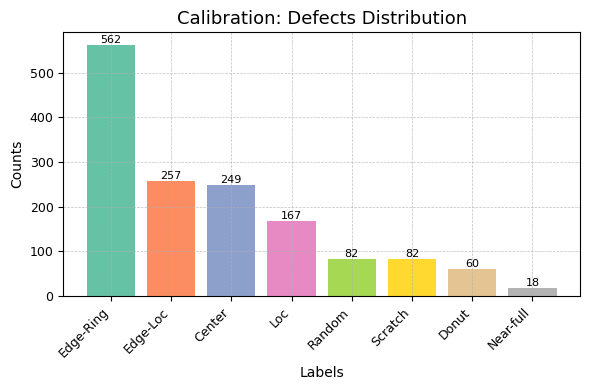

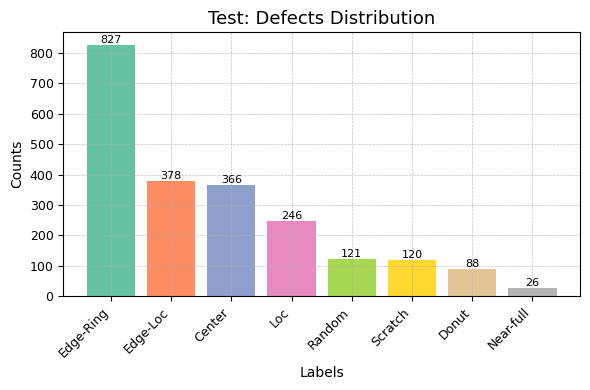

In [9]:
plot_label_distribution(cal, label_col='labels', title='Calibration: Defects Distribution')
plot_label_distribution(test, label_col='labels', title='Test: Defects Distribution')

## **6. Augmented calibration set**

In [10]:
# Base path
path = "/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/WMDD_application/dataset/dataaugmented/cal"
file_name = "calib_augmented.csv"
base_path = os.path.join(path, file_name)

# Load and preprocess dataset
dfaug = (
    pd.read_csv(base_path, index_col=0)
    .reset_index()
    .assign(set="cal", image_type="aug_std", image=lambda df: df["image_id"].map(os.path.basename))
)

# Generate full image paths using a lambda to pass base_path
dfaug["image_id"] = dfaug.apply(lambda row: image_path_generation_aug(row, path), axis=1)

dfaug.head(4)

,image_id,labels,set,image_type,image
0,/content/drive/MyDrive/Conformal_Prediction_Re...,Edge-Loc,cal,aug_std,wf_image_10784_0.png
1,/content/drive/MyDrive/Conformal_Prediction_Re...,Edge-Loc,cal,aug_std,wf_image_6153_1.png
2,/content/drive/MyDrive/Conformal_Prediction_Re...,Edge-Loc,cal,aug_std,wf_image_284_2.png
3,/content/drive/MyDrive/Conformal_Prediction_Re...,Edge-Loc,cal,aug_std,wf_image_1062_3.png


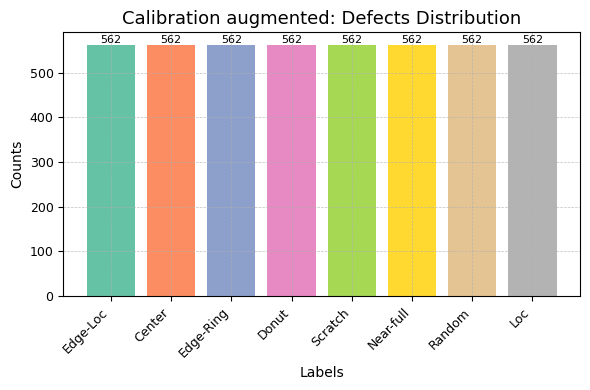

calibration augmented dataset size: (4496, 2)


In [11]:
cal_aug = dfaug[dfaug['set'] == 'cal'][['labels', 'image_id']].reset_index(drop=True)
cal_aug = pd.concat([cal, cal_aug], ignore_index=True).sample(frac=1).reset_index(drop=True)
plot_label_distribution(cal_aug, label_col='labels', title='Calibration augmented: Defects Distribution')
print('calibration augmented dataset size:', cal_aug.shape)

## **7. Prediction on test and calibration dataset**

In [12]:
cal['labels']=cal.labels.map(cfg.label2int)
cal_aug['labels']=cal_aug.labels.map(cfg.label2int)
test['labels']=test.labels.map(cfg.label2int)

print(np.sort(cal['labels'].unique()))
print(np.sort(cal_aug['labels'].unique()))
print(np.sort(test['labels'].unique()))

[0 1 2 3 4 5 6 7]
[0 1 2 3 4 5 6 7]
[0 1 2 3 4 5 6 7]


In [13]:
labels, labels_id = [val for val in cfg.label2int.keys()],[key for key in cfg.label2int.values()]
print(labels_id)
print(labels)

[0, 1, 2, 3, 4, 5, 6, 7]
['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Random', 'Scratch', 'Near-full']


In [14]:
test_dataset = TrainDataset(test, transform=get_transforms(data='valid', cfg=cfg))
test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False,
                 num_workers=cfg.num_workers, pin_memory=True)

cal_dataset = TrainDataset(cal, transform=get_transforms(data='valid', cfg=cfg))
cal_loader = DataLoader(cal_dataset, batch_size=cfg.batch_size, shuffle=False,
                 num_workers=cfg.num_workers, pin_memory=True)

cal_aug_dataset = TrainDataset(cal_aug, transform=get_transforms(data='valid', cfg=cfg))
cal_aug_loader = DataLoader(cal_aug_dataset, batch_size=cfg.batch_size, shuffle=False,
                 num_workers=cfg.num_workers, pin_memory=True)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [15]:
test_dataset = TrainDataset(test, transform=get_transforms(data='valid', cfg=cfg))
test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False,
                 num_workers=0, pin_memory=True) #cfg.num_workers

cal_dataset = TrainDataset(cal, transform=get_transforms(data='valid', cfg=cfg))
cal_loader = DataLoader(cal_dataset, batch_size=cfg.batch_size, shuffle=False,
                 num_workers=0, pin_memory=True)

cal_aug_dataset = TrainDataset(cal_aug, transform=get_transforms(data='valid', cfg=cfg))
cal_aug_loader = DataLoader(cal_aug_dataset, batch_size=cfg.batch_size, shuffle=False,
                 num_workers=0, pin_memory=True)

In [16]:
print(len(test_dataset))
print(len(test_loader))
print(len(cal_dataset))
print(len(cal_loader))
print(len(cal_aug_dataset))
print(len(cal_aug_loader))

2172
136
1477
93
4496
281


In [17]:
# Select device: use GPU if available, otherwise fallback to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model checkpoint, mapping tensors to the appropriate device (CPU if no CUDA available)
state_dict = torch.load(
    '/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/WMDD_application/models/tf_efficientnet_b0_ns_best.pth',
    map_location=device,  # Ensures compatibility on CPU-only machines
    weights_only=False
)

# Initialize model with specified configuration, and move it to the selected device
model = Model_type(cfg.model_name, pretrained=False, cfg=cfg).to(device)

# Load the weights from the checkpoint into the model
# Set strict=False to allow partial loading (in case some keys don't match)
model.load_state_dict(state_dict['model'], strict=False)

# Suppress automatic output display
_ = model

/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name tf_efficientnet_b0_ns to current tf_efficientnet_b0.ns_jft_in1k.
  model = create_fn(


In [18]:
# Compute probabilities for each dataset
cal_probs = get_model_probs(model, cal_loader, device)
cal_aug_probs = get_model_probs(model, cal_aug_loader, device)
test_probs = get_model_probs(model, test_loader, device)

  0%|          | 0/93 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Prepare true labels and predictions for the test set
y_true = test.labels.values
y_pred = test_probs.argmax(axis=1)

# Verify if the results from the trained model match those from the loaded model
evaluate_model(y_true, y_pred, test_probs)

## **8. Class-conformal prediction**
We compute the marginal, classwise, and clustered methods on the calibration dataset, and the classwise method on the augmented dataset.

In [ ]:
numclasses = len(cal['labels'].unique())
# prepare the different datasets
cal_labels, cal_smx = prepare_data(cal, cal_probs)
cal_aug_labels, cal_aug_smx = prepare_data(cal_aug, cal_aug_probs)
test_labels, test_smx = prepare_data(test, test_probs)


In [ ]:
#for  get_APS_scores_all function
cfg.seed = 0         #for  get_APS_scores_all function
cal_scores = get_APS_scores_all(cal_smx, randomize=cfg.randomize, seed=cfg.seed)
cal_aug_scores = get_APS_scores_all(cal_aug_smx, randomize=cfg.randomize, seed=cfg.seed)
test_scores = get_APS_scores_all(test_smx, randomize=cfg.randomize, seed=cfg.seed)

In [ ]:
results_aug = []

for i in tqdm(range(cfg.n_sim), desc="Simulazioni"):
    cfg.seed = i
    cal_scores_APS = get_APS_scores_all(cal_smx, randomize=cfg.randomize, seed=cfg.seed)
    cal_aug_scores_APS = get_APS_scores_all(cal_aug_smx, randomize=cfg.randomize, seed=cfg.seed)
    test_scores_APS = get_APS_scores_all(test_smx, randomize=cfg.randomize, seed=cfg.seed)


    cal_scores_RAPS = get_RAPS_scores_all(cal_smx, lmbda=.01, kreg=5, randomize=cfg.randomize, seed=cfg.seed)
    cal_aug_scores_RAPS = get_RAPS_scores_all(cal_aug_smx, lmbda=.01, kreg=5, randomize=cfg.randomize, seed=cfg.seed)
    test_scores_RAPS = get_RAPS_scores_all(test_smx, lmbda=.01, kreg=5, randomize=cfg.randomize, seed=cfg.seed)

    cal_scores_STD = 1 - cal_smx
    cal_aug_scores_STD = 1 - cal_aug_smx
    test_scores_STD = 1 - test_smx

    # Store the global variables required for the selected method
    if cfg.score == 'APS':
        globals()['cal_scores_APS'] = cal_scores_APS
        globals()['cal_aug_scores_APS'] = cal_aug_scores_APS
        globals()['test_scores_APS'] = test_scores_APS
    elif cfg.score == 'RAPS':
        globals()['cal_scores_RAPS'] = cal_scores_RAPS
        globals()['cal_aug_scores_RAPS'] = cal_aug_scores_RAPS
        globals()['test_scores_RAPS'] = test_scores_RAPS
    elif cfg.score == 'STD':
        globals()['cal_scores_STD'] = cal_scores_STD
        globals()['cal_aug_scores_STD'] = cal_aug_scores_STD
        globals()['test_scores_STD'] = test_scores_STD
    else:
        raise ValueError(f"Unknown score type: {cfg.score}")

    # Ora possiamo richiamare set_scores senza errori
    set_scores(cfg.score)

    with contextlib.redirect_stdout(io.StringIO()):
            _, _, marginal_coverage_metrics, marginal_set_size_metrics = standard_conformal(cal_scores, cal_labels, test_scores, test_labels, alpha=cfg.alpha)
            _, _, classwise_coverage_metrics, classwise_set_size_metrics = classwise_conformal(cal_scores, cal_labels, test_scores, test_labels, alpha=cfg.alpha, num_classes=numclasses)
            _, _, clustered_cov_metrics, clustered_set_size_metrics = clustered_conformal(cal_scores, cal_labels, alpha=cfg.alpha, val_scores_all=test_scores, val_labels=test_labels)
            _, _, coverage_metrics_aug, set_size_metrics_aug = classwise_conformal(cal_aug_scores, cal_aug_labels, test_scores, test_labels, alpha=cfg.alpha, num_classes=numclasses)

    results_aug.append({
            'seed': cfg.seed,
            'marginal_cov_gap': marginal_coverage_metrics['mean_class_cov_gap'],
            'marginal_set_size': marginal_set_size_metrics['mean'],
            'classwise_cov_gap': classwise_coverage_metrics['mean_class_cov_gap'],
            'classwise_set_size': classwise_set_size_metrics['mean'],
            'clust_cov_gap': clustered_cov_metrics['mean_class_cov_gap'],
            'clust_set_size': clustered_set_size_metrics['mean'],
            'class_aug_cov_gap': coverage_metrics_aug['mean_class_cov_gap'],
            'class_aug_set_size': set_size_metrics_aug['mean']
        })

    # 6. Final summary
results_df = pd.DataFrame(results_aug)



In [ ]:
# 6. Final summary
results_df = pd.DataFrame(results_aug)

def format_mean_std(series):
        return f"{series.mean():.3f} ({series.std():.4f})"

table_df = pd.DataFrame({
        "Method": ["Marginal", "Classwise", "Clustered", "Augmented"],
        "CovGap": [
            format_mean_std(results_df["marginal_cov_gap"]),
            format_mean_std(results_df["classwise_cov_gap"]),
            format_mean_std(results_df["clust_cov_gap"]),
            format_mean_std(results_df["class_aug_cov_gap"]),
        ],
        "AvgSize": [
            format_mean_std(results_df["marginal_set_size"]),
            format_mean_std(results_df["classwise_set_size"]),
            format_mean_std(results_df["clust_set_size"]),
            format_mean_std(results_df["class_aug_set_size"]),
        ]
    })
table_df

In [ ]:
# Apply the parsing function to extract mean and standard error
table_df[['CovGap_mean', 'CovGap_se']] = table_df['CovGap'].apply(lambda x: pd.Series(split_mean_se(x)))
table_df[['AvgSize_mean', 'AvgSize_se']] = table_df['AvgSize'].apply(lambda x: pd.Series(split_mean_se(x)))

In [ ]:

fig, axs = plot_covgap_avgsize_single(
    summary_df=table_df,
    covgap_y_column="CovGap_mean",    covgap_yerr_column="CovGap_se",
    avgsize_y_column="AvgSize_mean",  avgsize_yerr_column="AvgSize_se",
    model=None,
    figure_title="EfficientNet-B0 Model",   # opzionale
    rotate_x=0, fontsize_xticks=6,
    save_path_pdf=cfg.intervalplot_dir+'wm811k_effnet_intervalplot.pdf'
    #save_path_pdf=cfg.intervalplot_dir+'wm811k_effnet_intervalplot.pdf'

)
plt.show()


In [ ]:
#plot_interval_cp(
#    table_df,
#    covgap_y_column='CovGap_mean',
#    covgap_yerr_column='CovGap_se',
#    avgsize_y_column='AvgSize_mean',
#    avgsize_yerr_column='AvgSize_se',
#    config=cfg, save_path=cfg.output_dir+'wm811k_effnet_intervalplot.pdf', title='EfficientNet-B0 Model')

In [ ]:
with contextlib.redirect_stdout(io.StringIO()):
            _, _, marginal_coverage_metrics, marginal_set_size_metrics = standard_conformal(cal_scores, cal_labels, test_scores, test_labels, alpha=cfg.alpha)
            _, _, classwise_coverage_metrics, classwise_set_size_metrics = classwise_conformal(cal_scores, cal_labels, test_scores, test_labels, alpha=cfg.alpha, num_classes=numclasses)
            _, _, clustered_cov_metrics, clustered_set_size_metrics = clustered_conformal(cal_scores, cal_labels, alpha=cfg.alpha, val_scores_all=test_scores, val_labels=test_labels)
            _, _, coverage_metrics_aug, set_size_metrics_aug = classwise_conformal(cal_aug_scores, cal_aug_labels, test_scores, test_labels, alpha=cfg.alpha, num_classes=numclasses)

In [ ]:
results_aug= {
            'marginal_cov_gap': marginal_coverage_metrics['mean_class_cov_gap'],
            'marginal_set_size': marginal_set_size_metrics['mean'],
            'classwise_cov_gap': classwise_coverage_metrics['mean_class_cov_gap'],
            'classwise_set_size': classwise_set_size_metrics['mean'],
            'clust_cov_gap': clustered_cov_metrics['mean_class_cov_gap'],
            'clust_set_size': clustered_set_size_metrics['mean'],
            'class_aug_cov_gap': coverage_metrics_aug['mean_class_cov_gap'],
            'class_aug_set_size': set_size_metrics_aug['mean']
        }
# 6. Final summary
results_df = pd.DataFrame([results_aug])

def format_mean_std(series):
      return f"{series.mean():.4f}"

table_df = pd.DataFrame({
    "Method": ["Marginal", "Classwise", "Clustered", "Augmented"],
    "CovGap": [
        format_mean_std(results_df["marginal_cov_gap"]),
        format_mean_std(results_df["classwise_cov_gap"]),
        format_mean_std(results_df["clust_cov_gap"]),
        format_mean_std(results_df["class_aug_cov_gap"]),
        ],
     "AvgSize": [
        format_mean_std(results_df["marginal_set_size"]),
        format_mean_std(results_df["classwise_set_size"]),
        format_mean_std(results_df["clust_set_size"]),
        format_mean_std(results_df["class_aug_set_size"]),
        ]
    })

table_df

In [ ]:
marginal_qhats, marginal_preds, marginal_coverage_metrics, marginal_set_size_metrics = standard_conformal(cal_scores, cal_labels, test_scores, test_labels, alpha=cfg.alpha)

In [ ]:
classwise_qhats, classwise_preds, classwise_coverage_metrics, classwise_set_size_metrics = classwise_conformal(cal_scores, cal_labels, test_scores, test_labels, alpha=cfg.alpha,
                         num_classes=numclasses, default_qhat=np.inf, regularize=False, exact_coverage=False)
print('classwise quantile:', classwise_qhats)

In [ ]:
qhats, clust_preds, clustered_cov_metrics, clustered_set_size_metrics = clustered_conformal(cal_scores, cal_labels,alpha=cfg.alpha,
                                                        val_scores_all=test_scores, val_labels=test_labels)

In [ ]:
classwise_qhats, classwise_preds_aug, coverage_metrics_aug, set_size_metrics_aug = classwise_conformal(cal_aug_scores, cal_aug_labels, test_scores, test_labels, alpha=cfg.alpha,
                         num_classes=numclasses, default_qhat=np.inf, regularize=False, exact_coverage=False)
print('classwise quantile:', classwise_qhats)